# Assay size distribution on the unique union of all train splits

The processed dataset has overlapping rows across split files 0-4. To avoid counting duplicated records, this notebook:

1. reads all `train.csv` files for a dataset across splits 0-4,
2. concatenates them,
3. removes duplicate rows across the full row contents,
4. counts the number of unique rows per `assay_id`,
5. plots the resulting assay-size distribution for kinodata, landrum, and omnivore.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

ASSAY = "assay_id"
DATA_ROOT = Path("../data")
DATASETS = {
    "kinodata": ("activities-chembl33_v0.5.csv", "assays.chembl_id"),
    "landrum": ("landrum.csv", "assay_id"),
    "omnivore": ("omnivore.csv", "assay_id"),
}

all_rows = []
for dataset_key, (file, assay_id_col) in DATASETS.items():
    df = pl.scan_csv(DATA_ROOT / file).rename({assay_id_col: ASSAY})
    assay_sizes = (
        df.group_by(ASSAY)
        .agg(pl.len().alias("assay_size"))
        .with_columns(pl.lit(dataset_key).alias("dataset"))
    )
    all_rows.append(assay_sizes)

sizes_df = pl.concat(all_rows, how="vertical_relaxed").collect()
print(
    sizes_df.group_by("dataset").agg(
        pl.min("assay_size").alias("min"),
        pl.median("assay_size").alias("median"),
        pl.max("assay_size").alias("max"),
    )
)
print(sizes_df.head())

shape: (3, 4)
┌──────────┬─────┬────────┬──────┐
│ dataset  ┆ min ┆ median ┆ max  │
│ ---      ┆ --- ┆ ---    ┆ ---  │
│ str      ┆ u32 ┆ f64    ┆ u32  │
╞══════════╪═════╪════════╪══════╡
│ omnivore ┆ 1   ┆ 8.0    ┆ 1407 │
│ kinodata ┆ 1   ┆ 2.0    ┆ 777  │
│ landrum  ┆ 18  ┆ 29.0   ┆ 168  │
└──────────┴─────┴────────┴──────┘
shape: (5, 3)
┌───────────────┬────────────┬──────────┐
│ assay_id      ┆ assay_size ┆ dataset  │
│ ---           ┆ ---        ┆ ---      │
│ str           ┆ u32        ┆ str      │
╞═══════════════╪════════════╪══════════╡
│ CHEMBL4774748 ┆ 1          ┆ kinodata │
│ CHEMBL3599390 ┆ 6          ┆ kinodata │
│ CHEMBL2072348 ┆ 1          ┆ kinodata │
│ CHEMBL3404496 ┆ 49         ┆ kinodata │
│ CHEMBL887681  ┆ 14         ┆ kinodata │
└───────────────┴────────────┴──────────┘


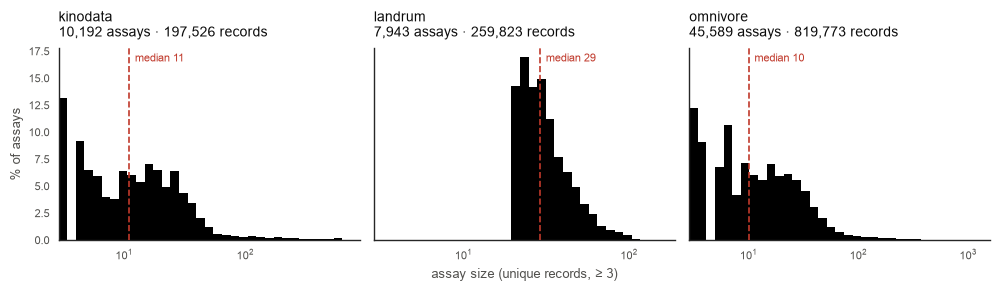

In [2]:
import seaborn as sns

sns.set_theme(context="paper", style="white")

MIN_ASSAY_SIZE = 3

BAR = "black"
ACCENT = "#c0392b"  # median marker, so it stays readable on the black bars
INK, INK_MUTED = "#0b0b0b", "#52514e"

sizes = {
    d: sizes_df.filter(
        (pl.col("dataset") == d) & (pl.col("assay_size") >= MIN_ASSAY_SIZE)
    )["assay_size"].to_numpy()
    for d in DATASETS
}

# x axis is not shared: every panel gets its own bins and limits
fig, axes = plt.subplots(1, 3, figsize=(10, 3.0), sharex=False, sharey=True)
for ax, dataset in zip(axes, DATASETS):
    s = sizes[dataset]
    bins = np.logspace(
        np.log10(MIN_ASSAY_SIZE) - 0.02, np.log10(s.max()) + 0.05, 36
    )
    ax.hist(
        s,
        bins=bins,
        weights=np.full(s.size, 100 / s.size),
        color=BAR,
        linewidth=0,
    )
    med = np.median(s)
    ax.axvline(med, color=ACCENT, linewidth=1.2, linestyle="--", zorder=3)
    ax.annotate(
        f"median {med:.0f}",
        xy=(med, 0.97),
        xycoords=("data", "axes fraction"),
        xytext=(4, 0),
        textcoords="offset points",
        ha="left",
        va="top",
        fontsize=8,
        color=ACCENT,
    )
    ax.set_xscale("log")
    ax.set_title(
        f"{dataset}\n{len(s):,} assays \u00b7 {s.sum():,} records",
        fontsize=10,
        color=INK,
        loc="left",
        pad=8,
    )
    ax.set_xlim(bins[0], bins[-1])
    ax.grid(False)
    ax.tick_params(labelsize=8, colors=INK_MUTED, length=3)

sns.despine(fig=fig)
axes[0].set_ylabel("% of assays", fontsize=9, color=INK_MUTED)
axes[1].set_xlabel(
    f"assay size (unique records, \u2265 {MIN_ASSAY_SIZE})",
    fontsize=9,
    color=INK_MUTED,
)

fig.tight_layout()
fig.savefig("assay_sizes.pdf")

plt.show()